# Facebook Live Sellers (Thailand) — K-Means Clustering

Questions from the project document:

1.	How does the time of upload (`status_published`)  affects the `num_reaction`?
2.	Is there a correlation between the number of reactions (num_reactions) and other engagement metrics such as comments (num_comments) and shares (num_shares)? If so, what is the strength and direction of this correlation?
3.	Use the columns status_type, num_reactions, num_comments, num_shares, num_likes, num_loves, num_wows, num_hahas, num_sads, and num_angrys to train a K-Means clustering model on the Facebook Live Sellers dataset.
4.	Use the elbow method to find the optimum number of clusters.
5.	What is the count of different types of posts in the dataset?
6.	What is the average value of num_reaction, num_comments, num_shares for each post type?



# Importing Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans


# Importing Dataset

In [6]:
df = pd.read_csv('Facebook_Marketplace_data.csv')

print("Shape (rows, cols):", df.shape)
df.head()


Shape (rows, cols): (7050, 16)


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


# Basic Data Cleaning (Dropping redundant columns, fixing date format)

In [7]:
# The dataset includes 4 redundant columns (Column1..Column4) that are fully empty (NaN).
# After removing them, we keep 12 useful columns.
redundant_cols = ["Column1", "Column2", "Column3", "Column4"]
df = df.drop(columns=[c for c in redundant_cols if c in df.columns])

print("After dropping redundant columns:", df.shape)
print("Columns:", df.columns.tolist())

# Convert 'status_published' into a single consistent datetime format
# (pandas can infer the month/day/year pattern from the data)
df["status_published"] = pd.to_datetime(df["status_published"], errors="coerce", infer_datetime_format=True)

# If any dates fail to parse, they become NaT (missing datetime).
print("Unparsed dates (NaT):", df["status_published"].isna().sum())

df.head()


After dropping redundant columns: (7050, 12)
Columns: ['status_id', 'status_type', 'status_published', 'num_reactions', 'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']
Unparsed dates (NaT): 0


/tmp/ipython-input-2291667653.py:11: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["status_published"] = pd.to_datetime(df["status_published"], errors="coerce", infer_datetime_format=True)


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0
1,2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0
2,3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0
3,4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0
4,5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0


# Handling Missing Values

In [8]:
# In this dataset, the main columns typically have no missing values.
# But we still build the model using an Imputer
# Quick missing value check:
df.isna().sum()


,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


# Q1) How does the time of upload (`status_published`)  affects the `num_reaction`?

Average num_reactions by hour:


,num_reactions
published_hour,
0,261.839474
1,203.315725
2,163.907618
3,290.270208
4,242.685864
5,293.870968
6,340.213198
7,183.301549
8,204.796897


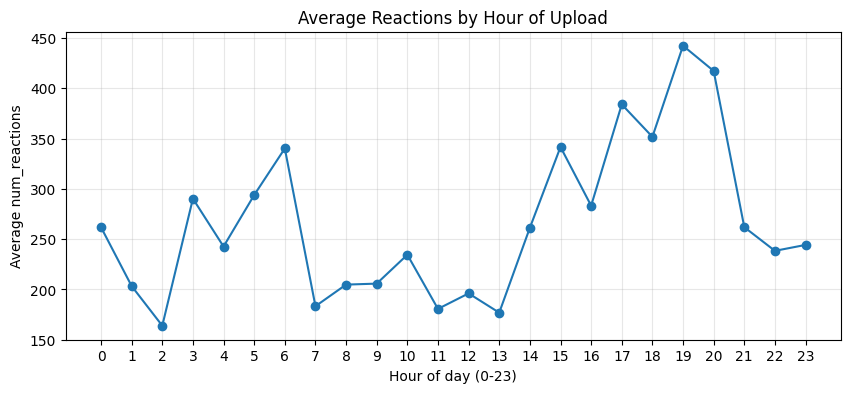

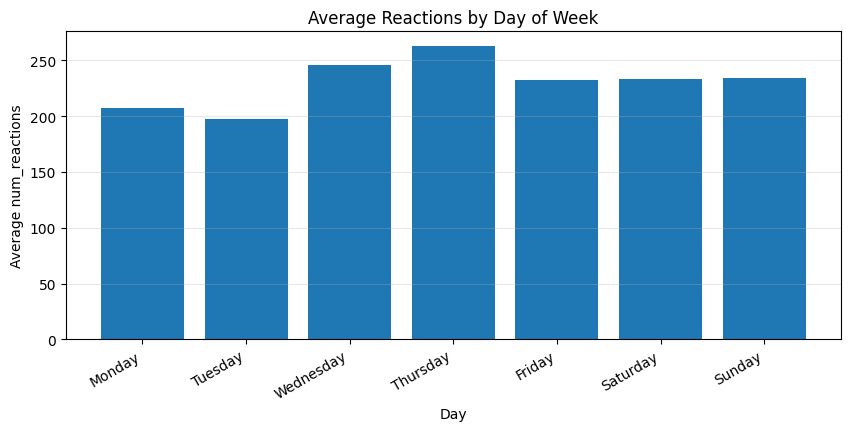

In [9]:
# Extract simple time-based features from the published datetime
df["published_hour"] = df["status_published"].dt.hour
df["published_day_name"] = df["status_published"].dt.day_name()

# 1) Average reactions by hour (0 to 23)
hourly = df.groupby("published_hour")["num_reactions"].mean().sort_index()

print("Average num_reactions by hour:")
display(hourly)

plt.figure(figsize=(10,4))
plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Average Reactions by Hour of Upload")
plt.xlabel("Hour of day (0-23)")
plt.ylabel("Average num_reactions")
plt.xticks(range(0,24,1))
plt.grid(True, alpha=0.3)
plt.show()

# 2) Average reactions by day of week (optional, still simple)
dow = df.groupby("published_day_name")["num_reactions"].mean()

# Keep days in a logical order
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = dow.reindex([d for d in day_order if d in dow.index])

plt.figure(figsize=(10,4))
plt.bar(dow.index, dow.values)
plt.title("Average Reactions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average num_reactions")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Interpretation tip:- Peaks in the line/bar plots show times/days when posts receive higher reactions on average.


# Q2) Is there a correlation between the number of reactions (num_reactions) and other engagement metrics such as comments (num_comments) and shares (num_shares)? If so, what is the strength and direction of this correlation?

Correlation matrix:


,num_reactions,num_comments,num_shares
num_reactions,1.000000,0.150843,0.250723
num_comments,0.150843,1.000000,0.640637
num_shares,0.250723,0.640637,1.000000


Corr(num_reactions, num_comments) = 0.15084290344217685
Corr(num_reactions, num_shares)   = 0.25072251662831907


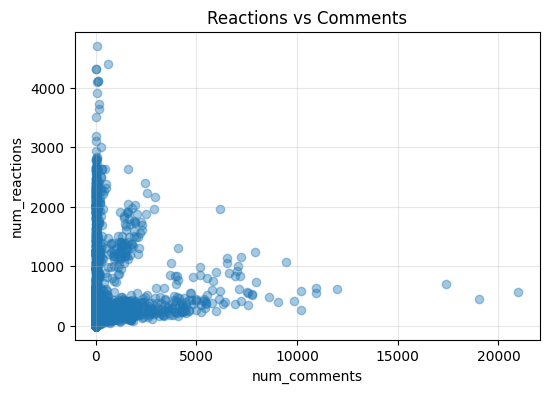

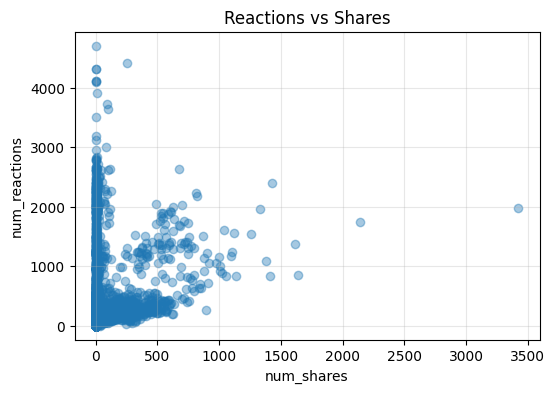

In [10]:
# Pearson correlation (common for numeric relationships)
corr_cols = ["num_reactions", "num_comments", "num_shares"]
corr = df[corr_cols].corr(method="pearson")

print("Correlation matrix:")
display(corr)

# Print the two most requested correlations clearly
print("Corr(num_reactions, num_comments) =", corr.loc["num_reactions", "num_comments"])
print("Corr(num_reactions, num_shares)   =", corr.loc["num_reactions", "num_shares"])

# Simple scatter plots to visually understand direction/strength
plt.figure(figsize=(6,4))
plt.scatter(df["num_comments"], df["num_reactions"], alpha=0.4)
plt.title("Reactions vs Comments")
plt.xlabel("num_comments")
plt.ylabel("num_reactions")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["num_shares"], df["num_reactions"], alpha=0.4)
plt.title("Reactions vs Shares")
plt.xlabel("num_shares")
plt.ylabel("num_reactions")
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation tip:
# - Positive correlation: as comments/shares increase, reactions tend to increase.
# - Value near 0: weak relationship; near 1: strong positive; near -1: strong negative.


# Q3) Use the columns status_type, num_reactions, num_comments, num_shares, num_likes, num_loves, num_wows, num_hahas, num_sads, and num_angrys to train a K-Means clustering model on the Facebook Live Sellers dataset.

**Preparing data for K-Means (Encoding + Scaling)**

In [11]:
# As asked, we train K-Means using:
features = [
    "status_type",
    "num_reactions", "num_comments", "num_shares",
    "num_likes", "num_loves", "num_wows", "num_hahas", "num_sads", "num_angrys"
]

X = df[features].copy()

# Categorical + numeric columns
cat_cols = ["status_type"]
num_cols = [c for c in features if c not in cat_cols]

# Preprocessing:
# 1) Missing values:
#    - categorical: most frequent (mode)
#    - numeric: median
# 2) Encoding:
#    - OneHotEncode 'status_type' so K-Means doesn't treat categories as numeric order
# 3) Feature scaling:
#    - StandardScaler for numeric + one-hot outputs (common for K-Means)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols)
    ]
)

# We'll reuse this preprocess step for elbow + final model.


# Q4) Using the Elbow Method to find the optimal number of clusters

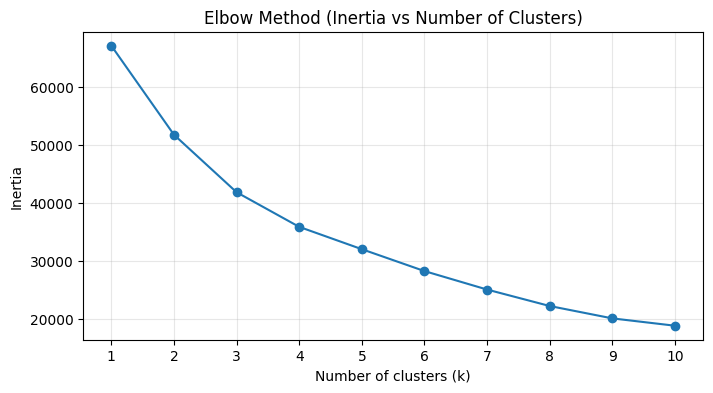

In [12]:
# Elbow method:
# - Fit KMeans for different k values and record inertia (within-cluster sum of squares).
# - The "elbow" point is where inertia stops decreasing sharply.

inertias = []
k_values = range(1, 11)

for k in k_values:
    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("kmeans", KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10))
    ])
    model.fit(X)
    inertias.append(model.named_steps["kmeans"].inertia_)

plt.figure(figsize=(8,4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method (Inertia vs Number of Clusters)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

# After seeing the elbow plot, set k_opt below.


# Training the K-Means model on the dataset

In [13]:
# Choose k based on the elbow curve you see above.
# (You can change this value easily if your elbow suggests a different k.)
k_opt = 3

kmeans_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("kmeans", KMeans(n_clusters=k_opt, init="k-means++", random_state=42, n_init=10))
])

kmeans_model.fit(X)

# Add cluster labels back to the original dataframe
df["cluster"] = kmeans_model.named_steps["kmeans"].labels_

df[["status_id", "status_type", "num_reactions", "num_comments", "num_shares", "cluster"]].head()


,status_id,status_type,num_reactions,num_comments,num_shares,cluster
0,1,video,529,512,262,1
1,2,photo,150,0,0,1
2,3,video,227,236,57,1
3,4,photo,111,0,0,1
4,5,photo,213,0,0,1


# Understanding / Interpreting Clusters (Simple summaries)

In [14]:
# 1) How many posts in each cluster?
cluster_counts = df["cluster"].value_counts().sort_index()
print("Cluster counts:")
display(cluster_counts)

# 2) Average engagement metrics per cluster (useful to understand cluster behavior)
cluster_profile = df.groupby("cluster")[
    ["num_reactions","num_comments","num_shares","num_likes","num_loves","num_wows","num_hahas","num_sads","num_angrys"]
].mean().round(2)

print("Cluster profile (average values):")
display(cluster_profile)

# 3) Distribution of post types inside each cluster
type_by_cluster = pd.crosstab(df["cluster"], df["status_type"], normalize="index").round(3)
print("Post type distribution within each cluster (row-wise %):")
display(type_by_cluster)

# Interpretation tip:
# - A cluster with high avg reactions/comments/shares likely represents "high engagement posts"
# - Another cluster might represent "low engagement posts"
# - status_type distribution shows which post types are common in each cluster


Cluster counts:


,count
cluster,
0,392
1,6386
2,272


Cluster profile (average values):


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
cluster,,,,,,,,,
0,1778.77,59.03,11.22,1772.97,3.10,2.47,0.19,0.03,0.01
1,111.35,106.37,21.68,102.77,7.48,0.54,0.34,0.15,0.06
2,786.57,3232.71,512.11,605.63,149.72,17.15,9.69,2.76,1.62


Post type distribution within each cluster (row-wise %):


status_type,link,photo,status,video
cluster,,,,
0,0.036,0.566,0.202,0.196
1,0.008,0.635,0.045,0.313
2,0.000,0.048,0.000,0.952


# Q5) What is the count of different types of posts in the dataset?

In [15]:
post_type_counts = df["status_type"].value_counts()
print("Count of each status_type:")
display(post_type_counts)


Count of each status_type:


,count
status_type,
photo,4288
video,2334
status,365
link,63


# Q6) What is the average value of num_reaction, num_comments, num_shares for each post type?

Average engagement per post type:


,num_reactions,num_comments,num_shares
status_type,,,
link,370.14,5.70,4.40
photo,181.29,15.99,2.55
status,438.78,36.24,2.56
video,283.41,642.48,115.68


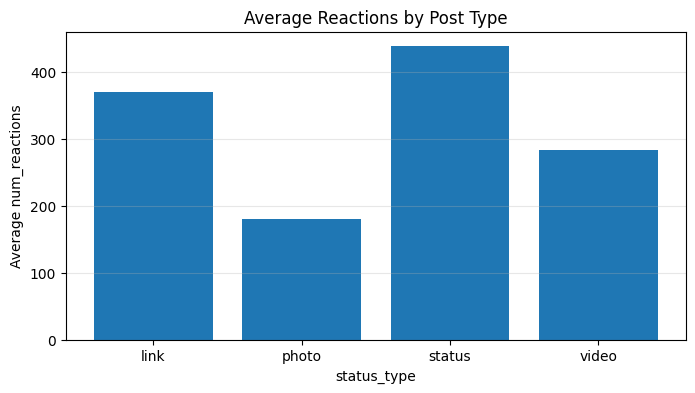

In [16]:
avg_by_type = df.groupby("status_type")[["num_reactions","num_comments","num_shares"]].mean().round(2)
print("Average engagement per post type:")
display(avg_by_type)

# Optional simple bar chart: avg reactions per type
plt.figure(figsize=(8,4))
plt.bar(avg_by_type.index, avg_by_type["num_reactions"].values)
plt.title("Average Reactions by Post Type")
plt.xlabel("status_type")
plt.ylabel("Average num_reactions")
plt.grid(True, axis="y", alpha=0.3)
plt.show()
